# XGBoost 模型实验

**数据集**：Give Me Some Credit（信用违约预测）  
**目标变量**：`SeriousDlqin2yrs`（1 = 未来两年内发生严重逾期，0 = 正常）  
**负责模块**：XGBoost（eXtreme Gradient Boosting）

## 实验流程
1. 读取预处理后的训练集与测试集
2. 用 SMOTE + `scale_pos_weight` 双重处理类别不平衡
3. `StratifiedKFold + RandomizedSearchCV` 超参数调优（以 ROC-AUC 为主指标）
4. 评估两个维度：**准确率**（Accuracy / ROC-AUC / PR-AUC）与**可解释性**（特征重要性 / SHAP 值）
5. 在保留测试集上报告最终 test error

> **关键原则**：测试集在训练和调参阶段全程不可见，仅在最终评估时使用一次。

In [1]:
# 安装依赖（第一次运行时执行，之后可跳过）
# Install dependencies (run once, then skip)
!pip install imbalanced-learn xgboost shap -q

## 1. 导入库 | Import Libraries

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_predict
)
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    roc_curve, auc, precision_recall_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import xgboost as xgb

import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
print(f'XGBoost version: {xgb.__version__}')
print('All libraries imported successfully.')

XGBoost version: 3.2.0
All libraries imported successfully.


## 2. 读取数据 | Load Data

In [3]:
def _find_data_dir():
    """自动定位 data 文件夹，兼容从不同目录启动 notebook 的情况"""
    candidates = [
        os.path.abspath(os.path.join(os.getcwd(), '..', 'data')),
        os.path.abspath(os.path.join(os.getcwd(), 'data')),
        'data',
    ]
    for d in candidates:
        if os.path.exists(os.path.join(d, 'X_train_processed.csv')):
            return d
    raise FileNotFoundError('找不到 data 目录，请确认 X_train_processed.csv 等文件存在。')

DATA_DIR = _find_data_dir()
print(f'Data directory: {DATA_DIR}')

# 训练集（用于调参和 CV）
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train_processed.csv'))
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train_processed.csv')).iloc[:, 0]

# 测试集（只在最终评估时使用一次）
X_test  = pd.read_csv(os.path.join(DATA_DIR, 'X_test_processed.csv'))
y_test  = pd.read_csv(os.path.join(DATA_DIR, 'y_test_processed.csv')).iloc[:, 0]

FEATURE_NAMES = list(X_train.columns)

print(f'Train set: X={X_train.shape}, y={y_train.shape}')
print(f'Test set:  X={X_test.shape},  y={y_test.shape}')
print(f'Number of features: {len(FEATURE_NAMES)}')
print()

vc    = y_train.value_counts()
ratio = y_train.value_counts(normalize=True) * 100
display(pd.DataFrame({'count': vc, 'ratio(%)': ratio.round(2)}))
print(f'Class imbalance ratio (neg:pos) ≈ {vc[0]/vc[1]:.1f}:1')

Data directory: c:\Users\Lenovo\Desktop\6122-group-project\data
Train set: X=(120000, 10), y=(120000,)
Test set:  X=(30000, 10),  y=(30000,)
Number of features: 10



,count,ratio(%)
SeriousDlqin2yrs,,
0,111979,93.32
1,8021,6.68


Class imbalance ratio (neg:pos) ≈ 14.0:1


## 3. 模型训练与超参数调优 | Training & Hyperparameter Tuning

### 思路说明

XGBoost（eXtreme Gradient Boosting）是基于 **Boosting** 的集成方法：串行训练多棵浅决策树，每棵新树专注于纠正前一棵树的残差，并加入正则化项防止过拟合。

**与 Random Forest 的主要区别**：
- Random Forest 并行训练（Bagging），XGBoost 串行训练（Boosting）
- XGBoost 内置 L1/L2 正则化（`reg_alpha` / `reg_lambda`）
- XGBoost 的 `scale_pos_weight` 参数原生支持类别不平衡

**类别不平衡处理（双重策略）**：
1. Pipeline 中加入 **SMOTE**（与其他模型保持一致）
2. XGBoost 的 `scale_pos_weight = 负样本数 / 正样本数 ≈ 14`（对少数类额外加权）

**超参数调优策略**：
- `StratifiedKFold(n_splits=5)`：5 折分层交叉验证
- `RandomizedSearchCV(n_iter=30)`：参数空间较大（共 108 种组合），随机采样 30 组加速搜索
- 以 `roc_auc` 为 refit 指标

In [4]:
# ── 计算 scale_pos_weight（负样本数 / 正样本数）
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
spw       = round(neg_count / pos_count, 2)

print(f'Negative samples (0): {neg_count},  Positive samples (1): {pos_count}')
print(f'scale_pos_weight = {neg_count} / {pos_count} ≈ {spw}')
print('(XGBoost uses this to up-weight the minority class and handle class imbalance)')

Negative samples (0): 111979,  Positive samples (1): 8021
scale_pos_weight = 111979 / 8021 ≈ 13.96
(XGBoost uses this to up-weight the minority class and handle class imbalance)


In [5]:
# Pipeline: SMOTE -> XGBClassifier (only SMOTE for class imbalance, consistent with other models)
xgb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   xgb.XGBClassifier(
        objective         = 'binary:logistic',
        eval_metric       = 'auc',
        use_label_encoder = False,
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbosity         = 0
    ))
])

xgb_param_dist = {
    'clf__n_estimators':     [200],
    'clf__max_depth':        [3, 5, 7],
    'clf__learning_rate':    [0.05, 0.1],
    'clf__subsample':        [0.8],
    'clf__colsample_bytree': [0.8],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

xgb_search = GridSearchCV(
    estimator  = xgb_pipeline,
    param_grid = xgb_param_dist,
    scoring    = {
        'roc_auc':           'roc_auc',
        'accuracy':          'accuracy',
        'average_precision': 'average_precision'
    },
    refit      = 'roc_auc',
    cv         = cv,
    return_train_score = True,
    n_jobs     = -1,
    verbose    = 1
)

print('Starting GridSearchCV (est. 5-10 min)...')
xgb_search.fit(X_train, y_train)

best_idx    = xgb_search.best_index_
cvr         = xgb_search.cv_results_
best_params = xgb_search.best_params_

print()
print('=' * 52)
print(f'Best params: {best_params}')
print(f'CV ROC-AUC  : {cvr["mean_test_roc_auc"][best_idx]:.4f} +/- {cvr["std_test_roc_auc"][best_idx]:.4f}')
print(f'CV Accuracy : {cvr["mean_test_accuracy"][best_idx]:.4f} +/- {cvr["std_test_accuracy"][best_idx]:.4f}')
print(f'CV PR-AUC   : {cvr["mean_test_average_precision"][best_idx]:.4f} +/- {cvr["std_test_average_precision"][best_idx]:.4f}')
print('=' * 52)

print()
print('Stage 2: Refit final model with best params + n_estimators=300...')
xgb_best = Pipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   xgb.XGBClassifier(
        objective         = 'binary:logistic',
        eval_metric       = 'auc',
        n_estimators      = 300,
        max_depth         = best_params['clf__max_depth'],
        learning_rate     = best_params['clf__learning_rate'],
        subsample         = best_params['clf__subsample'],
        colsample_bytree  = best_params['clf__colsample_bytree'],
        use_label_encoder = False,
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbosity         = 0
    ))
])
xgb_best.fit(X_train, y_train)
print('Final model trained (300 rounds).')

Starting GridSearchCV (est. 5-10 min)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
CV ROC-AUC  : 0.8472 +/- 0.0028
CV Accuracy : 0.8257 +/- 0.0032
CV PR-AUC   : 0.3596 +/- 0.0057

Stage 2: Refit final model with best params + n_estimators=300...
Final model trained (300 rounds).


## 4. 交叉验证曲线（无偏估计）| CV ROC & PR Curves

Computing OOF (Out-of-Fold) probability predictions...


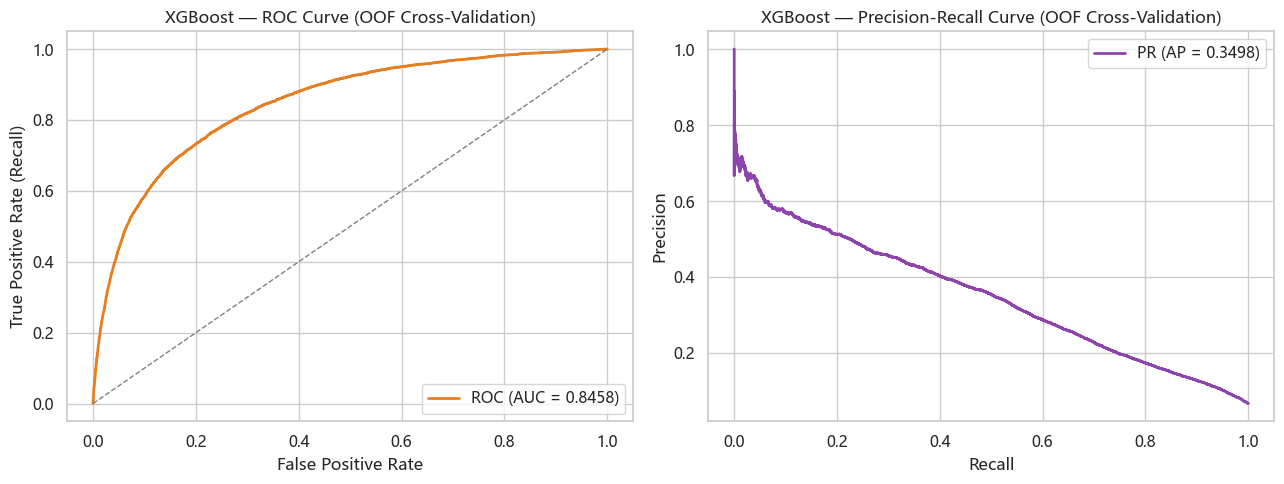

OOF ROC-AUC = 0.8458
OOF PR-AUC  = 0.3498

Note: ROC-AUC measures overall discriminative power (higher = better).
      PR-AUC is more informative under class imbalance (sensitive to minority class).


In [6]:
# ── Out-of-Fold 预测，绘制无偏 ROC / PR 曲线
print('Computing OOF (Out-of-Fold) probability predictions...')
xgb_oof_proba = cross_val_predict(
    xgb_best, X_train, y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

# ── ROC 曲线
fpr, tpr, _ = roc_curve(y_train, xgb_oof_proba)
roc_auc_cv  = auc(fpr, tpr)

# ── PR 曲线
precision, recall, _ = precision_recall_curve(y_train, xgb_oof_proba)
pr_auc_cv = average_precision_score(y_train, xgb_oof_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='#e67e22', lw=2,
             label=f'ROC (AUC = {roc_auc_cv:.4f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('XGBoost — ROC Curve (OOF Cross-Validation)')
axes[0].legend(loc='lower right')

axes[1].plot(recall, precision, color='#8e44ad', lw=2,
             label=f'PR (AP = {pr_auc_cv:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('XGBoost — Precision-Recall Curve (OOF Cross-Validation)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f'OOF ROC-AUC = {roc_auc_cv:.4f}')
print(f'OOF PR-AUC  = {pr_auc_cv:.4f}')
print()
print('Note: ROC-AUC measures overall discriminative power (higher = better).')
print('      PR-AUC is more informative under class imbalance (sensitive to minority class).')

## 5. 特征重要性 | Feature Importance

XGBoost 提供三种内置重要性指标：
- **weight**：特征被用作分裂依据的总次数
- **gain**：特征每次分裂带来的平均增益（与 Random Forest 的 Gini 重要性含义更接近）
- **cover**：特征每次分裂覆盖的平均样本数

这里使用 **gain**，可与 Random Forest 的 Gini 重要性进行横向对比。

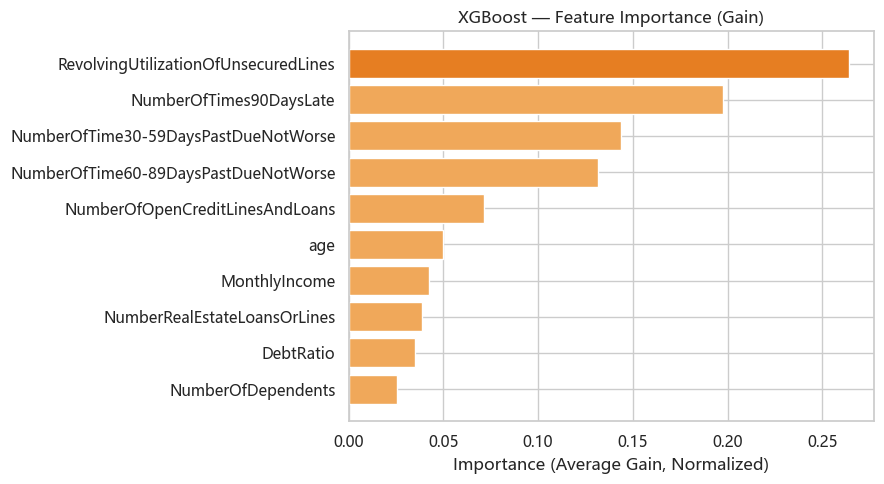

Feature importances (descending, normalized Gain):


,feature,importance
0,RevolvingUtilizationOfUnsecuredLines,0.2641
1,NumberOfTimes90DaysLate,0.1974
2,NumberOfTime30-59DaysPastDueNotWorse,0.1439
3,NumberOfTime60-89DaysPastDueNotWorse,0.1314
4,NumberOfOpenCreditLinesAndLoans,0.0714
5,age,0.0499
6,MonthlyIncome,0.0426
7,NumberRealEstateLoansOrLines,0.0388
8,DebtRatio,0.0350
9,NumberOfDependents,0.0253


In [7]:
xgb_clf = xgb_best.named_steps['clf']   # 从 Pipeline 中取出 XGBoost 分类器

# 获取 gain 重要性（未出现的特征 gain=0）
imp_gain = xgb_clf.get_booster().get_score(importance_type='gain')
imp_arr  = np.array([imp_gain.get(f, 0.0) for f in FEATURE_NAMES])
imp_norm = imp_arr / imp_arr.sum()   # 归一化

imp_df = pd.DataFrame({
    'feature':    FEATURE_NAMES,
    'importance': imp_norm
}).sort_values('importance', ascending=False).reset_index(drop=True)

# ── 可视化
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e67e22' if i == 0 else '#f0a85a' for i in range(len(imp_df))]
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importance (Average Gain, Normalized)')
ax.set_title('XGBoost — Feature Importance (Gain)')
plt.tight_layout()
plt.show()

print('Feature importances (descending, normalized Gain):')
display(imp_df.round(4))

## 6. 可解释性分析：SHAP 值 | SHAP Analysis

SHAP（SHapley Additive exPlanations）基于博弈论的 Shapley 值，为**每条样本的每个特征**分配一个贡献值：
- **正值（红色）**：该特征将违约概率推高
- **负值（蓝色）**：该特征将违约概率压低

XGBoost 的 `TreeExplainer` 计算速度很快，适合在较大数据集上使用。

SHAP Beeswarm Plot (each dot = one sample):


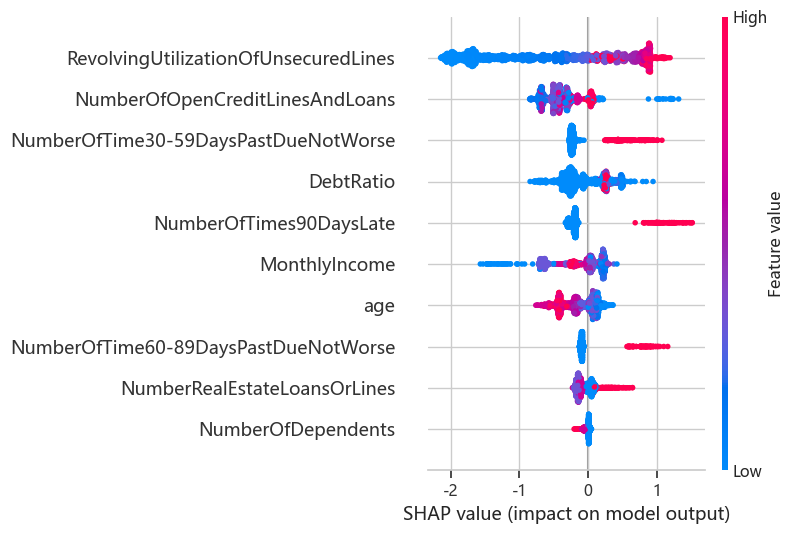

SHAP Bar Plot (mean |SHAP| value):


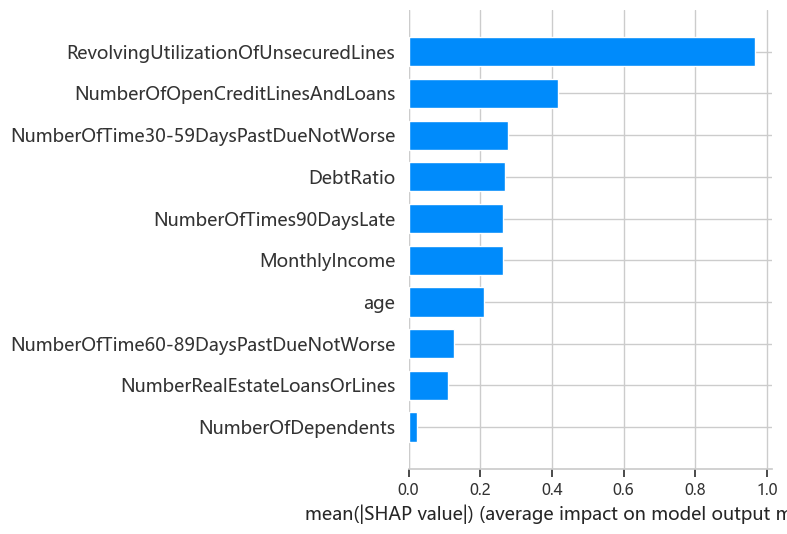

In [8]:
# 取 2000 个样本计算 SHAP（全量数据较慢）
shap_idx   = np.random.RandomState(RANDOM_STATE).choice(len(X_train), size=2000, replace=False)
X_shap     = X_train.iloc[shap_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_shap)

# ── Beeswarm Plot：每个点是一个样本，颜色代表特征值高低
print('SHAP Beeswarm Plot (each dot = one sample):')
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES,
                  plot_type='dot', show=True)

# ── Bar Plot：平均 |SHAP| 值
print('SHAP Bar Plot (mean |SHAP| value):')
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES,
                  plot_type='bar', show=True)

### 6.1 SHAP Dependence Plot（单特征深入分析）

选取最重要的特征，绘制其特征值与 SHAP 值的关系，进一步揭示非线性影响。

Top SHAP feature: RevolvingUtilizationOfUnsecuredLines


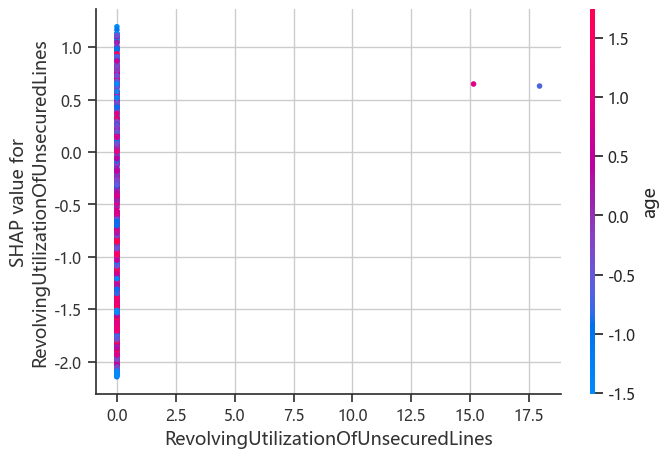

In [9]:
# 自动选取 SHAP 绝对值均值最高的特征
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx  = int(np.argmax(mean_abs_shap))
top_feature_name = FEATURE_NAMES[top_feature_idx]

print(f'Top SHAP feature: {top_feature_name}')
shap.dependence_plot(
    top_feature_idx, shap_values, X_shap,
    feature_names=FEATURE_NAMES,
    show=True
)

## 7. 测试集最终评估 | Final Test Set Evaluation

> ⚠️ 此单元格仅在完成全部训练和调参后运行一次。测试集结果代表模型在真实未见数据上的泛化性能（test error）。

  XGBoost — Final Test Set Results
  Accuracy : 0.8543
  ROC-AUC  : 0.8505
  PR-AUC   : 0.3559


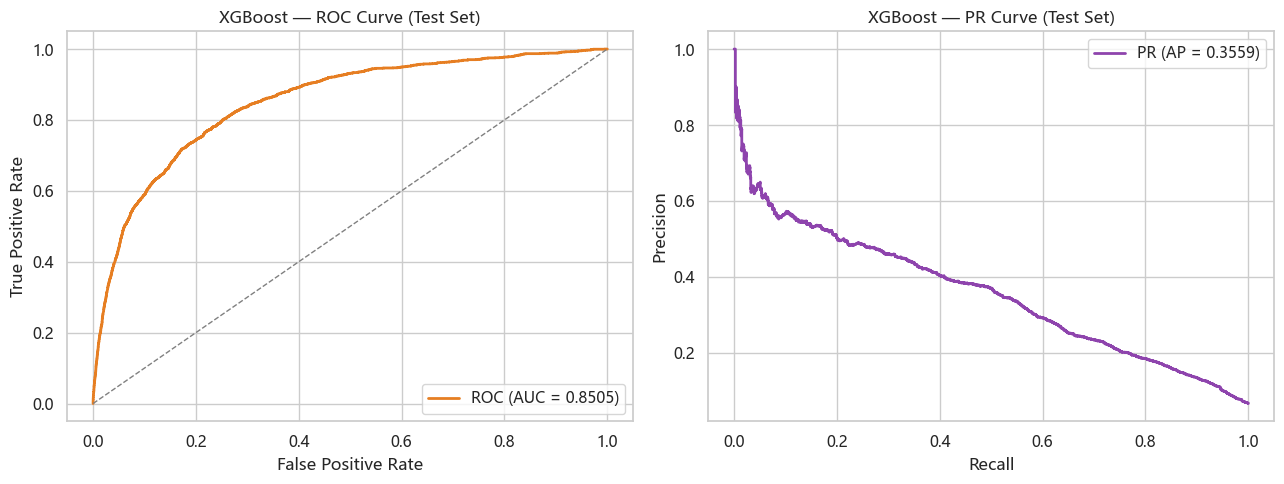

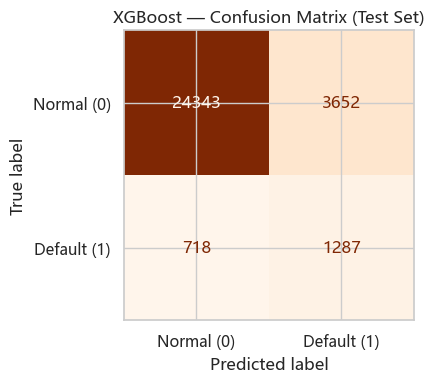

Classification Report:
              precision    recall  f1-score   support

  Normal (0)     0.9713    0.8695    0.9176     27995
 Default (1)     0.2606    0.6419    0.3707      2005

    accuracy                         0.8543     30000
   macro avg     0.6160    0.7557    0.6442     30000
weighted avg     0.9238    0.8543    0.8811     30000



In [10]:
y_pred  = xgb_best.predict(X_test)
y_proba = xgb_best.predict_proba(X_test)[:, 1]

test_acc     = accuracy_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_proba)
test_pr_auc  = average_precision_score(y_test, y_proba)

print('=' * 45)
print('  XGBoost — Final Test Set Results')
print('=' * 45)
print(f'  Accuracy : {test_acc:.4f}')
print(f'  ROC-AUC  : {test_roc_auc:.4f}')
print(f'  PR-AUC   : {test_pr_auc:.4f}')
print('=' * 45)

# ── ROC + PR 曲线
fpr_t, tpr_t, _   = roc_curve(y_test, y_proba)
prec_t, rec_t, _  = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr_t, tpr_t, color='#e67e22', lw=2,
             label=f'ROC (AUC = {test_roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('XGBoost — ROC Curve (Test Set)')
axes[0].legend(loc='lower right')

axes[1].plot(rec_t, prec_t, color='#8e44ad', lw=2,
             label=f'PR (AP = {test_pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('XGBoost — PR Curve (Test Set)')
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

# ── 混淆矩阵
cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Normal (0)', 'Default (1)']).plot(
    ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('XGBoost — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

# ── 分类报告
print('Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['Normal (0)', 'Default (1)'], digits=4))

## 8. 分析总结 | Summary

### 方法说明
- **数据拆分**：训练集:测试集 = 80:20，stratified sampling 保证类别分布一致
- **类别不平衡**：双重处理——Pipeline 中 SMOTE 过采样 + `scale_pos_weight ≈ 14`
- **交叉验证**：`StratifiedKFold(n_splits=5)`，以 ROC-AUC 为优化目标
- **超参数搜索**：`RandomizedSearchCV(n_iter=30)`，随机采样 `learning_rate / max_depth / n_estimators / subsample / colsample_bytree`

### 主要挑战
1. **类别不平衡**：Accuracy 具有欺骗性，应以 ROC-AUC 和 PR-AUC 为主要参考指标
2. **计算成本**：XGBoost 参数空间较大（108 种组合），使用 RandomizedSearchCV 控制搜索时间
3. **模型解释**：Gain 重要性与 SHAP 值结合使用，前者给出全局排序，后者揭示特征值方向与个体贡献